# Metastatic Selection Dataset

**Source data:** TRACERx Renal (Turajlic et al. 2018, *Cell*) Supplementary Tables S1 and S6.

**Research question:** Among mutations/copy-number events that were *subclonal* in the primary tumor, which ones get **selected** (become clonal) in the metastasis, and which are **lost**? This is the exact mechanism the paper's own analysis (Table S3) identifies as dominant ("subclonal-to-clonal selection... the prevalent mechanism"), reframed here as a supervised learning problem with real per-event labels.



In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

MMC1_PATH = "mmc1.xlsx"  # Table S1: clinical / tumor characteristics
MMC6_PATH = "mmc6.xlsx"  # Table S6: mutation and SCNA calls, primary vs metastasis status

## 1. Load and standardize the three event tables

`mmc6.xlsx` contains three sheets of molecular events, each recording whether an event was clonal/subclonal in the primary tumor and in the metastasis:
- **SNV_INDEL_DNV** — point mutations and small indels (targeted panel sequencing)
- **driverSCNA** — copy-number events at known driver loci
- **arm level SCNA** — chromosome-arm-level copy-number events

We standardize all three into one long table with a common schema.

In [4]:
xl6 = pd.ExcelFile(MMC6_PATH)

snv = xl6.parse('SNV_INDEL_DNV', header=0)
snv_std = pd.DataFrame({
    'event_id': snv['ID'],
    'gene_or_locus': snv['Gene.refGene'],
    'event_category': 'SNV_INDEL_DNV',
    'event_subtype': snv['event.type'],
    'exonic_function': snv['ExonicFunc.refGene'],
    'deleterious': snv['deleterious'],
    'patient': snv['patient'],
    'met_site': snv['met site'],
    'primary_status': snv['primary_status'],
    'met_status': snv['met_status'],
    'comment': snv['comment'],
})

dscna = xl6.parse('driverSCNA', header=0)
dscna_std = pd.DataFrame({
    'event_id': dscna['ID'],
    'gene_or_locus': dscna['ID'].str.replace(r'^(Gain|Loss)_', '', regex=True),
    'event_category': 'driverSCNA',
    'event_subtype': dscna['ID'].str.extract(r'^(Gain|Loss)')[0],
    'exonic_function': None,
    'deleterious': None,
    'patient': dscna['patient'],
    'met_site': dscna['met site'],
    'primary_status': dscna['primary_status'],
    'met_status': dscna['met_status'],
    'comment': dscna['comment'],
})

ascna = xl6.parse('arm level SCNA', header=0)
ascna_std = pd.DataFrame({
    'event_id': ascna['ID'],
    'gene_or_locus': ascna['ID'].str.replace(r'^(gain|loss)_', '', regex=True),
    'event_category': 'armSCNA',
    'event_subtype': ascna['ID'].str.extract(r'^(gain|loss)')[0].str.capitalize(),
    'exonic_function': None,
    'deleterious': None,
    'patient': ascna['patient'],
    'met_site': ascna['met site'],
    'primary_status': ascna['primary_status'],
    'met_status': ascna['met_status'],
    'comment': ascna['comment'],
})

events = pd.concat([snv_std, dscna_std, ascna_std], ignore_index=True)
print("Combined event table shape:", events.shape)
events['event_category'].value_counts()

Combined event table shape: (2177, 11)


event_category
armSCNA          1179
driverSCNA        511
SNV_INDEL_DNV     487
Name: count, dtype: int64

In [5]:
def label_row(row):
    if row['primary_status'] == 'subclonal' and row['met_status'] == 'clonal':
        return 'selected'
    if row['primary_status'] == 'subclonal' and pd.isna(row['met_status']):
        return 'not_selected'
    if row['primary_status'] == 'subclonal' and row['met_status'] == 'subclonal':
        return 'retained_subclonal'
    if row['primary_status'] == 'clonal':
        return 'already_clonal'
    if pd.isna(row['primary_status']):
        return 'de_novo_in_met'
    return 'other'

events['selection_label'] = events.apply(label_row, axis=1)
events['selection_label'].value_counts()

selection_label
not_selected          755
already_clonal        692
selected              440
de_novo_in_met        192
retained_subclonal     98
Name: count, dtype: int64

## 3. Merge in patient-level covariates

From `mmc1.xlsx` Table S1A (demographics, histology, stage, grade) and Table S1E (evolutionary subtype, whole-genome instability index [wGII], intratumor heterogeneity [ITH] index) — these give tumor-level context that may modulate selection probability.

In [6]:
xl1 = pd.ExcelFile(MMC1_PATH)

s1a = xl1.parse('Table S1A', header=3).dropna(subset=['Subject'])
s1a_slim = s1a[['Subject', 'Sex', 'Age', 'Histology', 'Sarcomatoid change (Y/N)',
                 'Overall Stage', 'Fuhrman Grade', 'Size of primary tumour (mm)']].rename(
    columns={'Subject': 'patient'})

s1e = xl1.parse('Table S1E', header=2).dropna(subset=['Patient'])
s1e_slim = s1e[['Patient', 'Evolutionary subtype', 'ITH/WGII group', 'Progression group',
                 'wGII', 'ITH Index']].rename(columns={'Patient': 'patient'})

merged = events.merge(s1a_slim, on='patient', how='left').merge(s1e_slim, on='patient', how='left')
print("Merged shape:", merged.shape)
print("Rows with full covariate match:", merged['Evolutionary subtype'].notna().sum(), "/", len(merged))
merged.to_csv('events_merged_full.csv', index=False)

Merged shape: (2177, 24)
Rows with full covariate match: 2177 / 2177


## 4. Build the final binary classification dataset

In [7]:
binary_df = merged[merged['selection_label'].isin(['selected', 'not_selected'])].copy()
binary_df['label'] = (binary_df['selection_label'] == 'selected').astype(int)

print("Total events:", len(binary_df))
print("Selected (label=1):", binary_df['label'].sum(), f"({binary_df['label'].mean():.1%})")
print("Not selected (label=0):", (1 - binary_df['label']).sum())
print("Unique patients:", binary_df['patient'].nunique())

binary_df.to_csv('binary_selection_dataset.csv', index=False)
binary_df.head()

Total events: 1195
Selected (label=1): 440 (36.8%)
Not selected (label=0): 755
Unique patients: 37


,event_id,gene_or_locus,event_category,event_subtype,exonic_function,deleterious,patient,met_site,primary_status,met_status,comment,selection_label,Sex,Age,Histology,Sarcomatoid change (Y/N),Overall Stage,Fuhrman Grade,Size of primary tumour (mm),Evolutionary subtype,ITH/WGII group,Progression group,wGII,ITH Index,label
2,MUC16_19:9066458:G:A,MUC16,SNV_INDEL_DNV,SNV,synonymous SNV,N,K059,THROMBUS_RV,subclonal,NaN,private.to.primary,not_selected,M,47.0,Clear Cell,N,III,3.0,170,PBRM1-->PI3K,C1_Lo_ITH_Lo_WGII,NaN,0.27,1.0,0
3,COL11A1_1:103467513:G:T,COL11A1,SNV_INDEL_DNV,SNV,nonsynonymous SNV,Y,K059,THROMBUS_RV,subclonal,NaN,private.to.primary,not_selected,M,47.0,Clear Cell,N,III,3.0,170,PBRM1-->PI3K,C1_Lo_ITH_Lo_WGII,NaN,0.27,1.0,0
4,MTOR_1:11188153:T:C,MTOR,SNV_INDEL_DNV,SNV,nonsynonymous SNV,Y,K059,THROMBUS_RV,subclonal,NaN,private.to.primary,not_selected,M,47.0,Clear Cell,N,III,3.0,170,PBRM1-->PI3K,C1_Lo_ITH_Lo_WGII,NaN,0.27,1.0,0
5,KMT2C_7:151921519:C:T,KMT2C,SNV_INDEL_DNV,SNV,.,Y,K059,THROMBUS_RV,subclonal,NaN,private.to.primary,not_selected,M,47.0,Clear Cell,N,III,3.0,170,PBRM1-->PI3K,C1_Lo_ITH_Lo_WGII,NaN,0.27,1.0,0
28,MGAM_7:141795477:C:A,MGAM,SNV_INDEL_DNV,SNV,nonsynonymous SNV,N,K107,THROMBUS_IVC,subclonal,NaN,private.to.primary,not_selected,M,62.0,Clear Cell,Y,IV,4.0,135,BAP1_driven,C3_Lo_ITH_Hi_WGII,Rapid,0.62,0.0,0


## 5. Sanity-check the signal before modeling

If this dataset has no real signal, no amount of modeling will produce anything meaningful. Check whether selection rate varies sensibly across known categories.

In [8]:
print("Selection rate by event category:")
print(binary_df.groupby('event_category')['label'].agg(['mean', 'count']))
print()
print("Selection rate by evolutionary subtype:")
print(binary_df.groupby('Evolutionary subtype')['label'].agg(['mean', 'count']).sort_values('count', ascending=False))
print()
print("Top loci/genes by event count and selection rate:")
print(binary_df.groupby('gene_or_locus')['label'].agg(['mean', 'count']).sort_values('count', ascending=False).head(15))

Selection rate by event category:
                    mean  count
event_category                 
SNV_INDEL_DNV   0.278261    230
armSCNA         0.351541    714
driverSCNA      0.498008    251

Selection rate by evolutionary subtype:
                             mean  count
Evolutionary subtype                    
BAP1_driven              0.410448    268
non_driver_subtype       0.220339    236
VHL_wt                   0.526066    211
PBRM1-->PI3K             0.283333    180
Multiple_Clonal_Drivers  0.521472    163
PBRM1-->SETD2            0.153846    117
PBRM1-->sCNA             0.650000     20

Top loci/genes by event count and selection rate:
                   mean  count
gene_or_locus                 
9p21.3         0.636364     33
15q            0.214286     28
SETD2          0.071429     28
20q13.33       0.538462     26
3q             0.230769     26
14q            0.576923     26
22q            0.440000     25
1p36.11        0.458333     24
7q22.3         0.500000     22
13q 

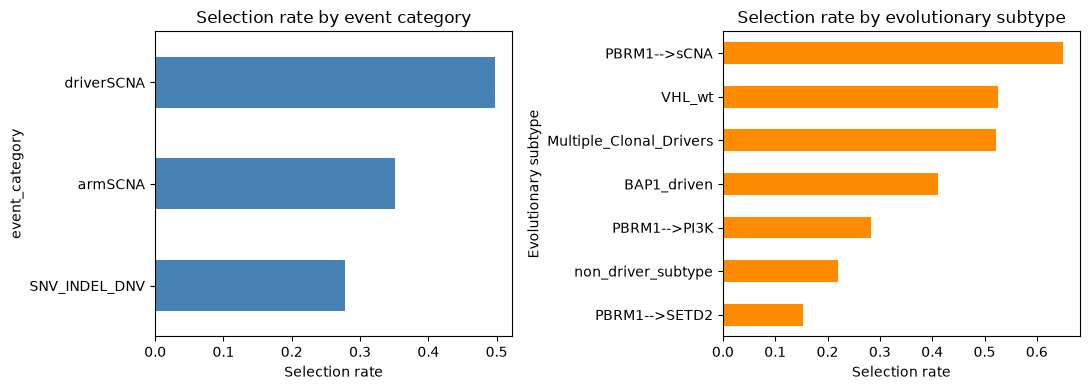

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cat_rates = binary_df.groupby('event_category')['label'].mean().sort_values()
cat_rates.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Selection rate')
axes[0].set_title('Selection rate by event category')

subtype_rates = binary_df.groupby('Evolutionary subtype')['label'].mean().sort_values()
subtype_rates.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('Selection rate')
axes[1].set_title('Selection rate by evolutionary subtype')

plt.tight_layout()

# Optional: Save as PDF for publication
# Save the plot at high resolution
plt.savefig(
    'selection_rate_by_category_subtype.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()